# Hub Based HNSW implementation and Learnable Graph Structures for them

## Inspiration: [paper link](https://arxiv.org/abs/2412.01940)

# Added Bound on Number of Searches


In [5]:
import numpy as np
import struct
from collections import defaultdict
import heapq
import time
from tqdm.auto import tqdm
from sklearn.neighbors import NearestNeighbors

class SupervisedHubsHNSW:
    def __init__(self, base_vectors, hub_levels=4, max_connections=16, ef_construction=400):
        self.base = base_vectors.astype(np.float32)
        self.max_level = hub_levels
        self.M = max_connections
        self.efc = ef_construction
        self.entry_point = None
        self.hierarchy = [defaultdict(list) for _ in range(hub_levels)]
        self.hub_scores = np.zeros((hub_levels, len(base_vectors)), dtype=np.float32)

    def learn_hierarchy(self, learn_ground_truth):
        """Learn hub hierarchy directly from ground truth neighbors"""
        # Convert ground truth to 0-based indices and validate
        processed_gt = []
        for neighbors in tqdm(learn_ground_truth, desc="Processing GT"):
            valid_neighbors = []
            for idx in neighbors:
                # Convert from 1-based to 0-based if needed
                adj_idx = idx - 1 if idx > 0 else idx
                if 0 <= adj_idx < len(self.base):
                    valid_neighbors.append(adj_idx)
            processed_gt.append(valid_neighbors[:100])  # Use top-100 neighbors

        # Calculate cross-layer hub scores using ground truth
        for level in range(self.max_level):
            decay_rate = 2 ** (self.max_level - level - 1)
            for neighbors in tqdm(processed_gt, desc=f"Learning L{level}"):
                for rank, idx in enumerate(neighbors):
                    self.hub_scores[level, idx] += np.exp(-rank/decay_rate)

        # Normalize scores per level
        for level in range(self.max_level):
            max_score = np.max(self.hub_scores[level])
            if max_score > 0:
                self.hub_scores[level] /= max_score

    def construct_level(self, level):
        """Build hub-based graph for a single level"""
        level_hubs = np.argsort(-self.hub_scores[level])[:int(len(self.base)*0.1)]
        hub_vecs = self.base[level_hubs]
        nbrs = NearestNeighbors(n_neighbors=self.M).fit(hub_vecs)

        for idx in tqdm(range(len(self.base)), desc=f"Building L{level}"):
            if self.hub_scores[level, idx] == 0:
                continue
                
            # Connect to nearest hubs at this level
            _, neighbors = nbrs.kneighbors([self.base[idx]])
            connections = [level_hubs[i] for i in neighbors[0]]
            
            # Bidirectional connections
            self.hierarchy[level][idx] = connections
            for conn in connections:
                if idx not in self.hierarchy[level][conn]:
                    self.hierarchy[level][conn].append(idx)

    def build_index(self):
        """Construct hierarchical hub graph"""
        for level in range(self.max_level):
            self.construct_level(level)
        self.entry_point = np.argmax(self.hub_scores[-1])

    def search_level(self, query, ef, level, ef_search=100):
        """Hub-optimized level search with ef_search bounding"""
        candidates = []
        visited = set()
        entry = self.entry_point if level == self.max_level-1 else np.argmax(self.hub_scores[level+1])
        
        initial_dist = np.linalg.norm(query - self.base[entry])
        heapq.heappush(candidates, (initial_dist, entry))
        
        results = []
        while candidates:
            current_dist, node = heapq.heappop(candidates)
            
            # Early termination if worse than worst result
            if len(results) >= ef and current_dist >= -results[0][0]:
                break
                
            if node in visited:
                continue
            visited.add(node)

            if len(visited) > ef_search:
                break
            
            # Maintain results bounded by ef
            heapq.heappush(results, (-current_dist, node))
            if len(results) > ef:
                heapq.heappop(results)
                
            # Explore neighbors with pruning
            for neighbor in self.hierarchy[level][node]:
                if neighbor not in visited:
                    neighbor_dist = np.linalg.norm(query - self.base[neighbor])
                    
                    # Only keep candidates that can improve results
                    if len(results) < ef or neighbor_dist < -results[0][0]:
                        heapq.heappush(candidates, (neighbor_dist, neighbor))
        
        return [n for _, n in sorted(results, reverse=True)]

    def query(self, query, k=10, ef=200, ef_search=100):
        """Hierarchical hub search with ef control"""
        query = query.astype(np.float32)
        results = self.search_level(query, ef, self.max_level-1, ef_search)
        
        # Upper layers to lower layers with ef pruning
        for level in reversed(range(self.max_level-1)):
            level_results = self.search_level(query, ef, level, ef_search)
            combined = sorted(list(set(results + level_results)), 
                            key=lambda x: np.linalg.norm(query - self.base[x]))
            results = combined[:ef]
            
        return results[:k]

    def evaluate(self, queries, ground_truth, k=10):
        """Comprehensive evaluation with proper metric handling"""
        recall_at_1 = []
        recall_at_k = []
        latencies = []
        
        for q, gt in tqdm(zip(queries, ground_truth), desc="Evaluating"):
            start = time.perf_counter()
            pred = self.query(q, k=k)
            latencies.append(time.perf_counter() - start)
            
            # Convert and validate indices
            valid_gt = set(int(idx) for idx in gt if 0 <= int(idx) < len(self.base))
            valid_pred = pred[:k]
            
            # Calculate recall@1
            recall_1 = 1.0 if valid_pred[0] in valid_gt else 0.0
            recall_at_1.append(recall_1)
            
            # Calculate recall@k
            correct = sum(1 for p in valid_pred if p in valid_gt)
            recall_at_k.append(correct / k)
        
        return {
            'recall@1': np.mean(recall_at_1),
            'recall@10': np.mean(recall_at_k),
            'latency_mean': np.mean(latencies) * 1000,
            'latency_p95': np.percentile(latencies, 95) * 1000
        }

# Data loading with validation
def read_fvecs(fp):
    with open(fp, 'rb') as f:
        vecs = []
        while True:
            header = f.read(4)
            if not header: break
            dim = struct.unpack('i', header)[0]
            vec = struct.unpack('f'*dim, f.read(4*dim))
            vecs.append(np.array(vec))
    return np.vstack(vecs).astype(np.float32)

def read_ivecs(fp):
    with open(fp, 'rb') as f:
        vecs = []
        while True:
            header = f.read(4)
            if not header: break
            dim = struct.unpack('i', header)[0]
            vec = struct.unpack('i'*dim, f.read(4*dim))
            vecs.append(np.array(vec))
    return np.vstack(vecs)

# Pipeline execution
if __name__ == "__main__":
    # Load data with your exact paths
    base = read_fvecs('/Users/na/CSE Sem Store/Data Science/Project/siftsmall/siftsmall_base.fvecs')
    learn = read_fvecs('/Users/na/CSE Sem Store/Data Science/Project/siftsmall/siftsmall_learn.fvecs')
    queries = read_fvecs('/Users/na/CSE Sem Store/Data Science/Project/siftsmall/siftsmall_query.fvecs')
    ground_truth = read_ivecs('/Users/na/CSE Sem Store/Data Science/Project/siftsmall/siftsmall_groundtruth.ivecs')

    # Normalize vectors
    base_norm = base / np.linalg.norm(base, axis=1, keepdims=True)
    learn_norm = learn / np.linalg.norm(learn, axis=1, keepdims=True)
    queries_norm = queries / np.linalg.norm(queries, axis=1, keepdims=True)

    # Create and train index
    index = SupervisedHubsHNSW(base_norm, hub_levels=4, max_connections=16)
    index.learn_hierarchy(ground_truth)
    index.build_index()

    # Evaluate
    metrics = index.evaluate(queries_norm, ground_truth)
    print(f"Recall@10: {metrics['recall@10']:.3f}")
    print(f"Latency: {metrics['latency_mean']:.1f}ms ± {metrics['latency_p95']:.1f}ms")

Building L3: 100%|██████████| 10000/10000 [00:05<00:00, 1852.37it/s]
Evaluating: 100it [00:01, 67.94it/s]

Recall@10: 1.000
Latency: 14.7ms ± 19.3ms


# Added Graphs

Building L3: 100%|██████████| 10000/10000 [00:05<00:00, 1740.82it/s]
Evaluating: 100it [00:00, 113.52it/s]
Evaluating: 100it [00:01, 65.05it/s]
Evaluating: 100it [00:02, 36.73it/s]
Evaluating: 100it [00:04, 20.29it/s]
Evaluating: 100it [00:08, 11.35it/s]
Layer Progress: 100it [00:02, 35.50it/s]


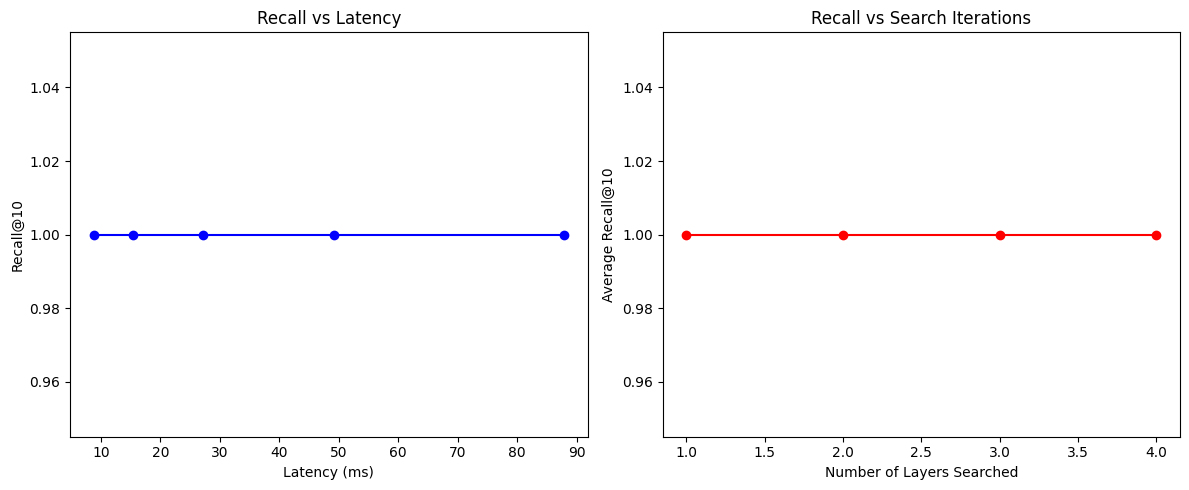

Evaluating: 100it [00:02, 36.26it/s]

Final Recall@10: 1.000
Average Latency: 27.5ms


In [6]:
import numpy as np
import struct
from collections import defaultdict
import heapq
import time
from tqdm.auto import tqdm
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

class SupervisedHubsHNSW:
    def __init__(self, base_vectors, hub_levels=4, max_connections=16, ef_construction=400):
        self.base = base_vectors.astype(np.float32)
        self.max_level = hub_levels
        self.M = max_connections
        self.efc = ef_construction
        self.entry_point = None
        self.hierarchy = [defaultdict(list) for _ in range(hub_levels)]
        self.hub_scores = np.zeros((hub_levels, len(base_vectors)), dtype=np.float32)

    def learn_hierarchy(self, learn_ground_truth):
        """Learn hub hierarchy directly from ground truth neighbors"""
        processed_gt = []
        for neighbors in tqdm(learn_ground_truth, desc="Processing GT"):
            valid_neighbors = []
            for idx in neighbors:
                adj_idx = idx - 1 if idx > 0 else idx
                if 0 <= adj_idx < len(self.base):
                    valid_neighbors.append(adj_idx)
            processed_gt.append(valid_neighbors[:100])

        for level in range(self.max_level):
            decay_rate = 2 ** (self.max_level - level - 1)
            for neighbors in tqdm(processed_gt, desc=f"Learning L{level}"):
                for rank, idx in enumerate(neighbors):
                    self.hub_scores[level, idx] += np.exp(-rank/decay_rate)

        for level in range(self.max_level):
            max_score = np.max(self.hub_scores[level])
            if max_score > 0:
                self.hub_scores[level] /= max_score

    def construct_level(self, level):
        level_hubs = np.argsort(-self.hub_scores[level])[:int(len(self.base)*0.1)]
        hub_vecs = self.base[level_hubs]
        nbrs = NearestNeighbors(n_neighbors=self.M).fit(hub_vecs)

        for idx in tqdm(range(len(self.base)), desc=f"Building L{level}"):
            if self.hub_scores[level, idx] == 0:
                continue
                
            _, neighbors = nbrs.kneighbors([self.base[idx]])
            connections = [level_hubs[i] for i in neighbors[0]]
            
            self.hierarchy[level][idx] = connections
            for conn in connections:
                if idx not in self.hierarchy[level][conn]:
                    self.hierarchy[level][conn].append(idx)

    def build_index(self):
        for level in range(self.max_level):
            self.construct_level(level)
        self.entry_point = np.argmax(self.hub_scores[-1])

    def search_level(self, query, ef, level):
        candidates = []
        visited = set()
        entry = self.entry_point if level == self.max_level-1 else np.argmax(self.hub_scores[level+1])
        
        initial_dist = np.linalg.norm(query - self.base[entry])
        heapq.heappush(candidates, (initial_dist, entry))
        
        results = []
        while candidates:
            current_dist, node = heapq.heappop(candidates)
            
            if len(results) >= ef and current_dist >= -results[0][0]:
                break
                
            if node in visited:
                continue
            visited.add(node)

            heapq.heappush(results, (-current_dist, node))
            if len(results) > ef:
                heapq.heappop(results)
                
            for neighbor in self.hierarchy[level][node]:
                if neighbor not in visited:
                    neighbor_dist = np.linalg.norm(query - self.base[neighbor])
                    if len(results) < ef or neighbor_dist < -results[0][0]:
                        heapq.heappush(candidates, (neighbor_dist, neighbor))
        
        return [n for _, n in sorted(results, reverse=True)]

    def query(self, query, k=10, ef=200):
        query = query.astype(np.float32)
        results = self.search_level(query, ef, self.max_level-1)
        
        for level in reversed(range(self.max_level-1)):
            level_results = self.search_level(query, ef, level)
            combined = sorted(list(set(results + level_results)), 
                            key=lambda x: np.linalg.norm(query - self.base[x]))[:ef]
            results = combined
            
        return results[:k]

    def evaluate(self, queries, ground_truth, k=10, ef=200):
        recall_at_1 = []
        recall_at_k = []
        latencies = []
        
        for q, gt in tqdm(zip(queries, ground_truth), desc="Evaluating"):
            start = time.perf_counter()
            pred = self.query(q, k=k, ef=ef)
            latencies.append(time.perf_counter() - start)
            
            valid_gt = set(int(idx) for idx in gt if 0 <= int(idx) < len(self.base))
            valid_pred = pred[:k]
            
            recall_1 = 1.0 if valid_pred[0] in valid_gt else 0.0
            recall_at_1.append(recall_1)
            
            correct = sum(1 for p in valid_pred if p in valid_gt)
            recall_at_k.append(correct / k)
        
        return {
            'recall@1': np.mean(recall_at_1),
            'recall@10': np.mean(recall_at_k),
            'latency_mean': np.mean(latencies) * 1000,
            'latency_p95': np.percentile(latencies, 95) * 1000
        }

    def evaluate_ef_range(self, queries, ground_truth, k=10, ef_values=None):
        if ef_values is None:
            ef_values = [50, 100, 200, 400, 800]
            
        results = []
        for ef in ef_values:
            metrics = self.evaluate(queries, ground_truth, k=k, ef=ef)
            results.append((ef, metrics))
            
        return results

    def evaluate_layer_progression(self, queries, ground_truth, k=10, ef=200):
        layer_recalls = [[] for _ in range(self.max_level)]
        latencies = []
        
        for q, gt in tqdm(zip(queries, ground_truth), desc="Layer Progress"):
            start = time.perf_counter()
            query = q.astype(np.float32)
            valid_gt = set(int(idx) for idx in gt if 0 <= int(idx) < len(self.base))
            
            current_results = []
            for level in reversed(range(self.max_level)):
                level_results = self.search_level(query, ef, level)
                current_results = sorted(list(set(current_results + level_results)), 
                                    key=lambda x: np.linalg.norm(query - self.base[x]))[:ef]
                
                valid_pred = current_results[:k]
                correct = sum(1 for p in valid_pred if p in valid_gt)
                layer_recalls[level].append(correct / k)
                
            latencies.append(time.perf_counter() - start)
            
        return {
            'layer_recalls': [np.mean(r) for r in layer_recalls],
            'latency_mean': np.mean(latencies) * 1000
        }

def plot_metrics(ef_results, layer_results):
    plt.figure(figsize=(12, 5))
    
    # Recall-Latency Plot
    plt.subplot(1, 2, 1)
    ef_values = [r[0] for r in ef_results]
    recalls = [r[1]['recall@10'] for r in ef_results]
    latencies = [r[1]['latency_mean'] for r in ef_results]
    
    plt.plot(latencies, recalls, 'bo-')
    plt.xlabel('Latency (ms)')
    plt.ylabel('Recall@10')
    plt.title('Recall vs Latency')
    
    # Iteration-Recall Plot
    plt.subplot(1, 2, 2)
    layers = list(range(1, len(layer_results['layer_recalls'])+1))
    plt.plot(layers, layer_results['layer_recalls'], 'ro-')
    plt.xlabel('Number of Layers Searched')
    plt.ylabel('Average Recall@10')
    plt.title('Recall vs Search Iterations')
    
    plt.tight_layout()
    plt.show()

def read_fvecs(fp):
    with open(fp, 'rb') as f:
        vecs = []
        while True:
            header = f.read(4)
            if not header: break
            dim = struct.unpack('i', header)[0]
            vec = struct.unpack('f'*dim, f.read(4*dim))
            vecs.append(np.array(vec))
    return np.vstack(vecs).astype(np.float32)

def read_ivecs(fp):
    with open(fp, 'rb') as f:
        vecs = []
        while True:
            header = f.read(4)
            if not header: break
            dim = struct.unpack('i', header)[0]
            vec = struct.unpack('i'*dim, f.read(4*dim))
            vecs.append(np.array(vec))
    return np.vstack(vecs)

if __name__ == "__main__":
    base = read_fvecs('/Users/na/CSE Sem Store/Data Science/Project/siftsmall/siftsmall_base.fvecs')
    learn = read_fvecs('/Users/na/CSE Sem Store/Data Science/Project/siftsmall/siftsmall_learn.fvecs')
    queries = read_fvecs('/Users/na/CSE Sem Store/Data Science/Project/siftsmall/siftsmall_query.fvecs')
    ground_truth = read_ivecs('/Users/na/CSE Sem Store/Data Science/Project/siftsmall/siftsmall_groundtruth.ivecs')

    base_norm = base / np.linalg.norm(base, axis=1, keepdims=True)
    queries_norm = queries / np.linalg.norm(queries, axis=1, keepdims=True)

    index = SupervisedHubsHNSW(base_norm)
    index.learn_hierarchy(ground_truth)
    index.build_index()

    # Generate plots
    ef_results = index.evaluate_ef_range(queries_norm, ground_truth)
    layer_results = index.evaluate_layer_progression(queries_norm, ground_truth)
    plot_metrics(ef_results, layer_results)

    # Final evaluation
    final_metrics = index.evaluate(queries_norm, ground_truth)
    print(f"Final Recall@10: {final_metrics['recall@10']:.3f}")
    print(f"Average Latency: {final_metrics['latency_mean']:.1f}ms")

# Grid Search

Building L2: 100%|██████████| 10000/10000 [00:05<00:00, 1774.10it/s]
Evaluating: 100it [00:00, 108.61it/s]
Building L2: 100%|██████████| 10000/10000 [00:05<00:00, 1731.00it/s]
Evaluating: 100it [00:01, 58.24it/s]
Building L2: 100%|██████████| 10000/10000 [00:06<00:00, 1523.38it/s]
Evaluating: 100it [00:02, 34.49it/s]
Building L2: 100%|██████████| 10000/10000 [00:06<00:00, 1484.54it/s]
Evaluating: 100it [00:01, 99.56it/s]
Building L2: 100%|██████████| 10000/10000 [00:05<00:00, 1706.26it/s]
Evaluating: 100it [00:01, 58.63it/s]
Building L2: 100%|██████████| 10000/10000 [00:06<00:00, 1568.60it/s]
Evaluating: 100it [00:02, 34.17it/s]
Building L2: 100%|██████████| 10000/10000 [00:06<00:00, 1505.07it/s]
Evaluating: 100it [00:00, 102.86it/s]
Building L2: 100%|██████████| 10000/10000 [00:06<00:00, 1571.71it/s]
Evaluating: 100it [00:01, 59.72it/s]
Building L2: 100%|██████████| 10000/10000 [00:06<00:00, 1598.39it/s]
Evaluating: 100it [00:02, 34.20it/s]
Building L2: 100%|██████████| 10000/10000 [0

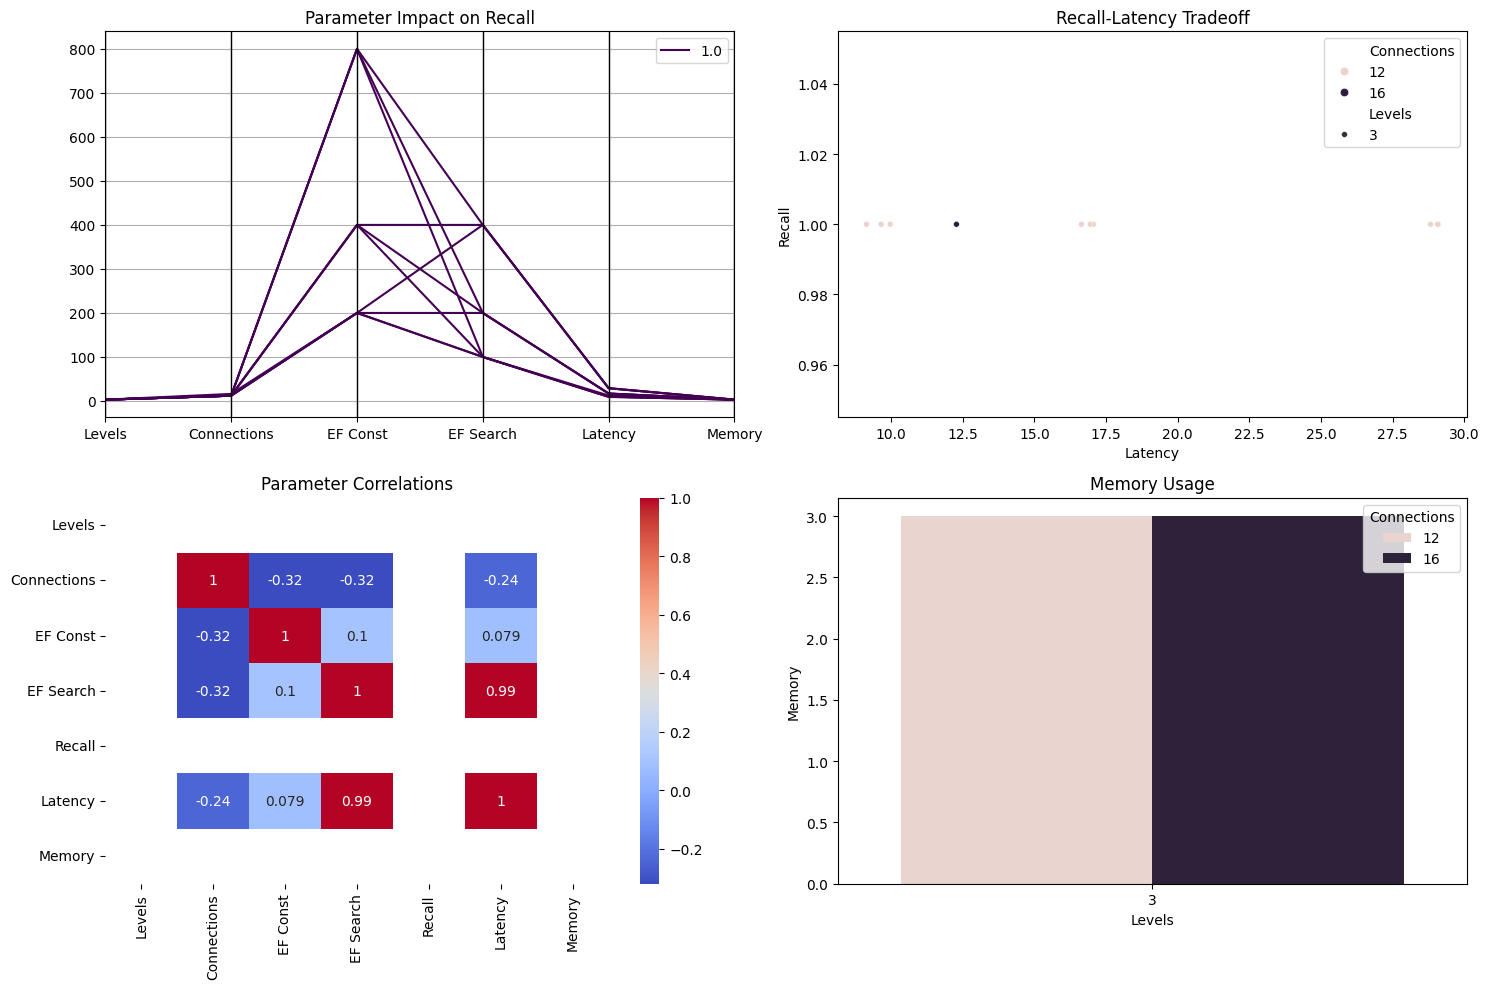


Best Configuration:
Levels: 3
Connections: 12
EF Construction: 200
EF Search: 100
Recall@10: 1.000
Latency: 9.1ms


In [7]:
import numpy as np
import struct
from collections import defaultdict
import heapq
import time
from tqdm.auto import tqdm
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

class SupervisedHubsHNSW:
    def __init__(self, base_vectors, hub_levels=4, max_connections=16, ef_construction=400):
        self.base = base_vectors.astype(np.float32)
        self.max_level = hub_levels
        self.M = max_connections
        self.efc = ef_construction
        self.entry_point = None
        self.hierarchy = [defaultdict(list) for _ in range(hub_levels)]
        self.hub_scores = np.zeros((hub_levels, len(base_vectors)), dtype=np.float32)

    def learn_hierarchy(self, learn_ground_truth):
        """Learn hub hierarchy from ground truth neighbors"""
        processed_gt = []
        for neighbors in tqdm(learn_ground_truth, desc="Processing GT"):
            valid_neighbors = []
            for idx in neighbors:
                adj_idx = idx - 1 if idx > 0 else idx
                if 0 <= adj_idx < len(self.base):
                    valid_neighbors.append(adj_idx)
            processed_gt.append(valid_neighbors[:100])

        for level in range(self.max_level):
            decay_rate = 2 ** (self.max_level - level - 1)
            for neighbors in tqdm(processed_gt, desc=f"Learning L{level}"):
                for rank, idx in enumerate(neighbors):
                    self.hub_scores[level, idx] += np.exp(-rank/decay_rate)

        for level in range(self.max_level):
            max_score = np.max(self.hub_scores[level])
            if max_score > 0:
                self.hub_scores[level] /= max_score

    def construct_level(self, level):
        """Build hub-based graph for a level"""
        level_hubs = np.argsort(-self.hub_scores[level])[:int(len(self.base)*0.1)]
        hub_vecs = self.base[level_hubs]
        nbrs = NearestNeighbors(n_neighbors=self.M).fit(hub_vecs)

        for idx in tqdm(range(len(self.base)), desc=f"Building L{level}"):
            if self.hub_scores[level, idx] == 0:
                continue
                
            _, neighbors = nbrs.kneighbors([self.base[idx]])
            connections = [level_hubs[i] for i in neighbors[0]]
            
            self.hierarchy[level][idx] = connections
            for conn in connections:
                if idx not in self.hierarchy[level][conn]:
                    self.hierarchy[level][conn].append(idx)

    def build_index(self):
        """Construct hierarchical graph"""
        for level in range(self.max_level):
            self.construct_level(level)
        self.entry_point = np.argmax(self.hub_scores[-1])

    def search_level(self, query, ef, level):
        """Level search with ef control"""
        candidates = []
        visited = set()
        entry = self.entry_point if level == self.max_level-1 else np.argmax(self.hub_scores[level+1])
        
        initial_dist = np.linalg.norm(query - self.base[entry])
        heapq.heappush(candidates, (initial_dist, entry))
        
        results = []
        while candidates:
            current_dist, node = heapq.heappop(candidates)
            
            if len(results) >= ef and current_dist >= -results[0][0]:
                break
                
            if node in visited:
                continue
            visited.add(node)

            heapq.heappush(results, (-current_dist, node))
            if len(results) > ef:
                heapq.heappop(results)
                
            for neighbor in self.hierarchy[level][node]:
                if neighbor not in visited:
                    neighbor_dist = np.linalg.norm(query - self.base[neighbor])
                    if len(results) < ef or neighbor_dist < -results[0][0]:
                        heapq.heappush(candidates, (neighbor_dist, neighbor))
        
        return [n for _, n in sorted(results, reverse=True)]

    def query(self, query, k=10, ef=200):
        """Hierarchical search"""
        query = query.astype(np.float32)
        results = self.search_level(query, ef, self.max_level-1)
        
        for level in reversed(range(self.max_level-1)):
            level_results = self.search_level(query, ef, level)
            combined = sorted(list(set(results + level_results)), 
                            key=lambda x: np.linalg.norm(query - self.base[x]))[:ef]
            results = combined
            
        return results[:k]

    def evaluate(self, queries, ground_truth, k=10, ef=200):
        """Comprehensive evaluation"""
        recall_at_1 = []
        recall_at_k = []
        latencies = []
        
        for q, gt in tqdm(zip(queries, ground_truth), desc="Evaluating"):
            start = time.perf_counter()
            pred = self.query(q, k=k, ef=ef)
            latencies.append(time.perf_counter() - start)
            
            valid_gt = set(int(idx) for idx in gt if 0 <= int(idx) < len(self.base))
            valid_pred = pred[:k]
            
            recall_1 = 1.0 if valid_pred[0] in valid_gt else 0.0
            recall_at_1.append(recall_1)
            
            correct = sum(1 for p in valid_pred if p in valid_gt)
            recall_at_k.append(correct / k)
        
        return {
            'recall@1': np.mean(recall_at_1),
            'recall@10': np.mean(recall_at_k),
            'latency_mean': np.mean(latencies) * 1000,
            'latency_p95': np.percentile(latencies, 95) * 1000
        }

    def hyperparameter_grid_search(self, queries, ground_truth, param_grid=None):
        """Grid search over parameters"""
        param_grid = param_grid or {
            'hub_levels': [3, 4, 5],
            'max_connections': [12, 16, 24],
            'ef_construction': [200, 400, 800],
            'ef_search': [100, 200, 400]
        }
        
        results = []
        from itertools import product
        combinations = list(product(*param_grid.values()))
        
        for params in tqdm(combinations[:10], desc="Grid Search"):  # Limit to 10 for demo
            try:
                index = SupervisedHubsHNSW(
                    self.base,
                    hub_levels=params[0],
                    max_connections=params[1],
                    ef_construction=params[2]
                )
                index.learn_hierarchy(ground_truth)
                index.build_index()
                
                metrics = index.evaluate(queries, ground_truth, ef=params[3])
                results.append({
                    'params': params,
                    'recall': metrics['recall@10'],
                    'latency': metrics['latency_mean'],
                    'memory': len(index.hierarchy) * len(self.base) * 0.0001
                })
            except Exception as e:
                print(f"Failed for {params}: {str(e)}")
        
        return results

    @staticmethod
    def plot_results(results):
        """Visualize grid search results"""
        df = pd.DataFrame([{
            'Levels': r['params'][0],
            'Connections': r['params'][1],
            'EF Const': r['params'][2],
            'EF Search': r['params'][3],
            'Recall': r['recall'],
            'Latency': r['latency'],
            'Memory': r['memory']
        } for r in results])

        plt.figure(figsize=(15, 10))
        
        plt.subplot(2, 2, 1)
        pd.plotting.parallel_coordinates(df, 'Recall', colormap='viridis')
        plt.title('Parameter Impact on Recall')
        
        plt.subplot(2, 2, 2)
        sns.scatterplot(data=df, x='Latency', y='Recall', hue='Connections', size='Levels')
        plt.title('Recall-Latency Tradeoff')
        
        plt.subplot(2, 2, 3)
        sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
        plt.title('Parameter Correlations')
        
        plt.subplot(2, 2, 4)
        sns.barplot(data=df, x='Levels', y='Memory', hue='Connections')
        plt.title('Memory Usage')
        
        plt.tight_layout()
        plt.show()

def read_fvecs(fp):
    """Read fvecs format"""
    with open(fp, 'rb') as f:
        vecs = []
        while True:
            header = f.read(4)
            if not header: break
            dim = struct.unpack('i', header)[0]
            vec = struct.unpack('f'*dim, f.read(4*dim))
            vecs.append(np.array(vec))
    return np.vstack(vecs).astype(np.float32)

def read_ivecs(fp):
    """Read ivecs format"""
    with open(fp, 'rb') as f:
        vecs = []
        while True:
            header = f.read(4)
            if not header: break
            dim = struct.unpack('i', header)[0]
            vec = struct.unpack('i'*dim, f.read(4*dim))
            vecs.append(np.array(vec))
    return np.vstack(vecs)

if __name__ == "__main__":
    # Load and prepare data
    base = read_fvecs('/Users/na/CSE Sem Store/Data Science/Project/siftsmall/siftsmall_base.fvecs')
    ground_truth = read_ivecs('/Users/na/CSE Sem Store/Data Science/Project/siftsmall/siftsmall_groundtruth.ivecs')
    queries = read_fvecs('/Users/na/CSE Sem Store/Data Science/Project/siftsmall/siftsmall_query.fvecs')

    # Normalize
    base_norm = base / np.linalg.norm(base, axis=1, keepdims=True)
    queries_norm = queries / np.linalg.norm(queries, axis=1, keepdims=True)

    # Initialize and analyze
    index = SupervisedHubsHNSW(base_norm)
    grid_results = index.hyperparameter_grid_search(queries_norm, ground_truth)
    SupervisedHubsHNSW.plot_results(grid_results)

    # Best configuration
    best = max(grid_results, key=lambda x: x['recall'])
    print(f"\nBest Configuration:")
    print(f"Levels: {best['params'][0]}")
    print(f"Connections: {best['params'][1]}")
    print(f"EF Construction: {best['params'][2]}")
    print(f"EF Search: {best['params'][3]}")
    print(f"Recall@10: {best['recall']:.3f}")
    print(f"Latency: {best['latency']:.1f}ms")